In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import plotly.graph_objects as go
from datetime import datetime
import yfinance as yf

In [ ]:
!pip install yfinance --upgrade

In [ ]:
# 🔕️ Load and prepare data from yfinance
end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)
data = yf.download('BTC-USD', start=start, end=end)
data.reset_index(inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
close_prices = data[['Date', 'Close']].copy()
data_values = close_prices[['Close']].values

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
data.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2015-06-07,222.880997,226.194000,222.651993,225.595993,13318400
1,2015-06-08,228.488998,229.464005,222.839005,222.878998,23378400
2,2015-06-09,229.048004,230.953995,227.929001,228.537994,28353100
3,2015-06-10,228.802994,229.781998,228.009995,228.994995,15904800
4,2015-06-11,229.705002,230.287003,228.766998,228.854996,14416000


In [ ]:
data.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
3649,2025-06-03,105432.468750,106813.578125,104920.843750,105888.476562,46196508367
3650,2025-06-04,104731.984375,105997.695312,104232.703125,105434.367188,44544857105
3651,2025-06-05,101575.953125,105936.687500,100436.882812,104750.781250,57479298400
3652,2025-06-06,104390.343750,105376.773438,101169.570312,101574.367188,48856653697
3653,2025-06-07,104980.781250,105067.382812,104067.367188,104391.664062,44881444864


In [ ]:
data.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3654,3654.000000,3654.000000,3654.000000,3654.000000,3.654000e+03
mean,2020-06-06 12:00:00,24217.473900,24716.354789,23639.789042,24190.049945,2.099203e+10
min,2015-06-07 00:00:00,210.494995,226.194000,199.567001,210.067993,1.060090e+07
25%,2017-12-06 06:00:00,4014.954102,4087.665100,3916.606812,4016.551208,3.558540e+09
50%,2020-06-06 12:00:00,11032.358398,11385.821777,10704.389160,11012.333008,1.748666e+10
75%,2022-12-06 18:00:00,39049.397461,39899.029297,37720.593750,38886.302734,3.199405e+10
max,2025-06-07 00:00:00,111673.281250,111970.171875,109285.070312,111679.359375,3.509679e+11
std,NaN,26494.120281,26997.268221,25910.783346,26464.692192,2.100285e+10


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           3654 non-null   datetime64[ns]
 1   (Close, BTC-USD)   3654 non-null   float64       
 2   (High, BTC-USD)    3654 non-null   float64       
 3   (Low, BTC-USD)     3654 non-null   float64       
 4   (Open, BTC-USD)    3654 non-null   float64       
 5   (Volume, BTC-USD)  3654 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 171.4 KB


In [ ]:
data.isnull()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
3649,False,False,False,False,False,False
3650,False,False,False,False,False,False
3651,False,False,False,False,False,False


In [ ]:
data.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [ ]:
#Close price data
closing_price = data[['Close']]

In [ ]:

closing_price['Close']

Ticker,BTC-USD
0,222.880997
1,228.488998
2,229.048004
3,228.802994
4,229.705002
...,...
3649,105432.468750
3650,104731.984375
3651,101575.953125
3652,104390.343750


In [ ]:
# 🔄 Normalize the full data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_values)

In [ ]:
# 🔁 Create sequences for GRU
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
# ✂️ Split the data
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# 🔨 Define the GRU Model
model = Sequential()
model.add(Input(shape=(60, 1)))
model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(50))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss=Huber())

In [ ]:
# 🔁 Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

In [ ]:
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

history = model.fit(X_train, y_train_scaled, epochs=100, batch_size=32, callbacks=[lr_scheduler, early_stop])

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - loss: 0.0134 - learning_rate: 5.0000e-04
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 3.3626e-04 - learning_rate: 5.0000e-04
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 2.7013e-04 - learning_rate: 5.0000e-04
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 2.6138e-04 - learning_rate: 5.0000e-04
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 3.0060e-04 - learning_rate: 5.0000e-04
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 2.4418e-04 - learning_rate: 2.5000e-04
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 2.4959e-04 - learning_rate: 2.5000e-04
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 2.3283e-04 - learning_rate: 2.5000e-04
Epoch 9/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 2.4475e-04 - learning_rate: 1.2500e-04
Epoch 10/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 2.3056e-04 - learning_rate: 1.2500e-04
Epoch

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib

# 1. Download historical Bitcoin prices
df = yf.download("BTC-USD", period="3y")
close_prices = df[["Close"]].dropna()

# 2. Fit the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(close_prices)

# 3. Save the scaler to disk
joblib.dump(scaler, "scaler_y.pkl")

print("✅ scaler_y.pkl has been saved successfully.")


[*********************100%***********************]  1 of 1 completed

✅ scaler_y.pkl has been saved successfully.


In [ ]:
# 🔍 Predict and inverse transform
predicted_scaled = model.predict(X_test)
predicted = scaler_y.inverse_transform(predicted_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_scaled)
print(y_test_actual.flatten())

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
[0.25225453 0.26750454 0.26647267 0.27349912 0.27218233 0.27156837
 0.26969213 0.27343358 0.26803341 0.27125517 0.27154136 0.2725536
 0.27282895 0.27763476 0.27423581 0.27187254 0.26644626 0.27033032
 0.26988421 0.26879589 0.27097811 0.27283058 0.27077335 0.28050217
 0.27025678 0.26991351 0.26949477 0.2685685  0.26597278 0.26648741
 0.26539369 0.26644094 0.26521235 0.2680181  0.25987526 0.2603281
 0.26147272 0.26017827 0.26115219 0.26149017 0.260758   0.26035251
 0.26435045 0.25965136 0.25989109 0.25895277 0.25866599 0.25866355
 0.25990812 0.26515574 0.26332555 0.26214217 0.26185618 0.26201992
 0.26082624 0.26195244 0.25981634 0.25561253 0.23733532 0.23181783
 0.23223634 0.2330741  0.23248697 0.23165724 0.23524574 0.23282998
 0.23180089 0.23144916 0.23217792 0.23232557 0.24687071 0.24301178
 0.23075843 0.22958541 0.23019615 0.23110019 0.2296903  0.22939932
 0.22915937 0.23352817 0.2305268  0.23043729 0.22986803 0.2238609
 0.22987806 0.23342167 0.

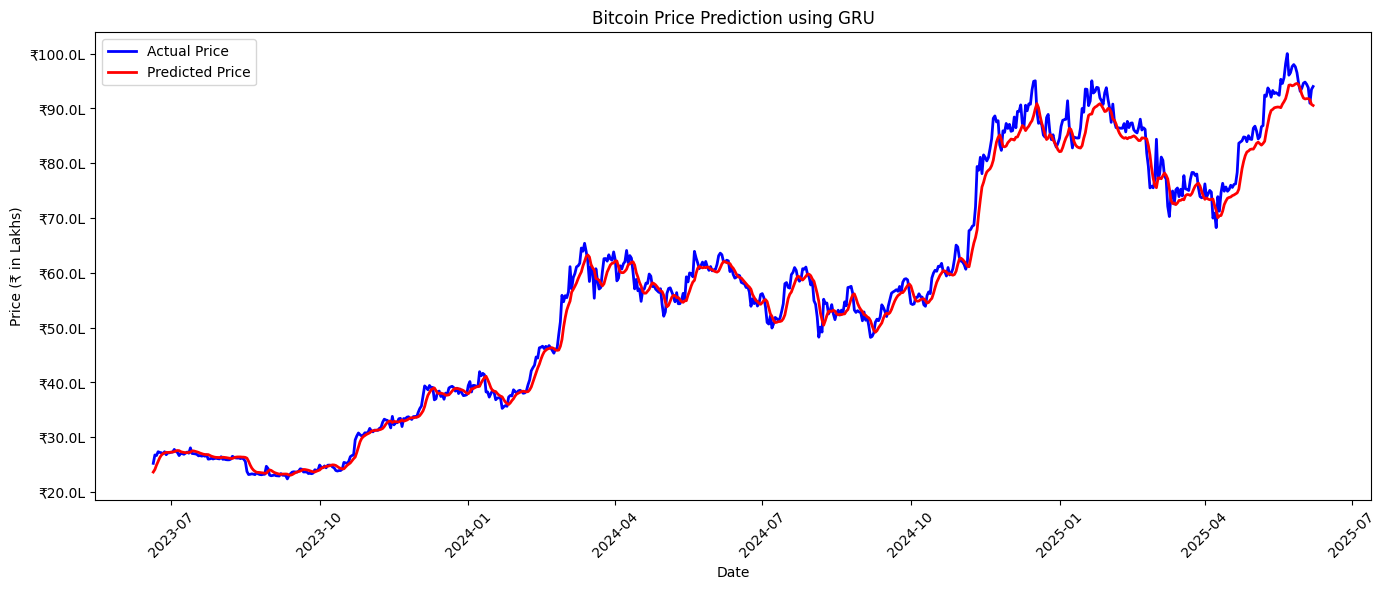

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd # Ensure pandas is imported here if not already



# Calculate the starting index for the test dates in the original 'data' DataFrame
test_start_index_in_data = train_size + sequence_length

# Get the dates for the test set from the original 'data' DataFrame
test_dates = data['Date'][test_start_index_in_data:test_start_index_in_data + len(y_test_actual)]

# Convert y-axis values to lakhs
y_actual_lakh = y_test_actual.flatten() * 100
y_predicted_lakh = predicted.flatten() *100

# Plot
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_actual_lakh, color='blue', label='Actual Price', linewidth=2)
plt.plot(test_dates, y_predicted_lakh, color='red', label='Predicted Price', linewidth=2)
plt.title('Bitcoin Price Prediction using GRU')
plt.xlabel('Date')
plt.ylabel('Price (₹ in Lakhs)')
plt.legend()

# Format y-axis ticks
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}L'))

# Rotate x-axis dates for clarity
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# 📊 Evaluation
rmse = np.sqrt(mean_squared_error(y_test_actual, predicted))
mae = mean_absolute_error(y_test_actual, predicted)
r2 = r2_score(y_test_actual, predicted)
mape = np.mean(np.abs((y_test_actual - predicted) / y_test_actual)) * 100

print(f'\n📊 Evaluation Metrics:')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score (≈ Accuracy): {r2:.4f}')
print(f'MAPE: {mape:.2f}%')


📊 Evaluation Metrics:
RMSE: 0.02
MAE: 0.02
R² Score (≈ Accuracy): 0.9886
MAPE: 2.82%


In [ ]:
# 📉 Plotly Interactive Chart with INR in Lakhs
import plotly.io as pio
import plotly.graph_objects as go # Import go
import numpy as np # Import numpy
import pandas as pd # Import pandas


# Convert to lakhs for better readability
predicted_lakh = predicted*100
actual_lakh = y_test_actual*100

# Format INR in lakhs as "81.5L" style
def inr_lakh_format(value):
    try:
        return f"{value:.1f}L"
    except:
        return value

# Only keep the relevant dates for test prediction
# Use the original 'data' DataFrame which contains the 'Date' column
# Calculate the starting index for the test dates in the original 'data' DataFrame
test_start_index_in_data = train_size + sequence_length

# Get the dates for the test set from the original 'data' DataFrame
test_dates = data['Date'][test_start_index_in_data:test_start_index_in_data + len(y_test_actual)]


fig = go.Figure()
fig.add_trace(go.Scatter(
    x=test_dates,
    y=actual_lakh.flatten(),
    mode='lines',
    name='Actual BTC Price',
    line=dict(color='green', width=2),
    hovertemplate='Date: %{x|%d %b %Y}<br>Actual: ₹%{y:.2f}L<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=test_dates,
    y=predicted_lakh.flatten(),
    mode='lines',
    name='Predicted BTC Price',
    line=dict(color='orange', dash='dot', width=2),
    hovertemplate='Date: %{x|%d %b %Y}<br>Predicted: ₹%{y:.2f}L<extra></extra>'
))

# Dynamically generate y-axis tick values
min_val = np.min(np.concatenate([actual_lakh, predicted_lakh]))
max_val = np.max(np.concatenate([actual_lakh, predicted_lakh]))
tick_vals = np.linspace(min_val, max_val, 10)
tick_text = [inr_lakh_format(val) for val in tick_vals]

fig.update_layout(
    title='📈 BTC Actual vs Predicted Prices (INR)',
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1D", step="day", stepmode="backward"),
                dict(count=5, label="5D", step="day", stepmode="backward"),
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(step="all", label="Max")
            ]),
            bgcolor='black',
            font=dict(color='white')
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    yaxis=dict(
        tickvals=tick_vals,
        ticktext=tick_text,
        title='Price (₹ in Lakhs)',
        tickfont=dict(size=12)
    ),
    hovermode='x unified',
    template='plotly_dark',
    height=500
)

fig.show()








In [ ]:
# 🔮 Future prediction (30 days ahead)
future_days = 30
seq_len = sequence_length  # use the same sequence length as during training

# Get the last `seq_len` days from scaled data to start prediction
last_seq = scaled_data[-seq_len:].reshape(1, seq_len, 1)

# Collect scaled predictions
future_scaled_predictions = []

for _ in range(future_days):
    # Predict the next value (scaled)
    next_scaled = model.predict(last_seq, verbose=0)[0, 0]
    future_scaled_predictions.append(next_scaled)

    # Update the sequence for next prediction
    last_seq = np.append(last_seq[:, 1:, :], [[[next_scaled]]], axis=1)

# Inverse transform to get original BTC prices
future_actual_prices = scaler_y.inverse_transform(np.array(future_scaled_predictions).reshape(-1, 1))
future_lakhs = future_actual_prices.flatten() * 100 # Convert to Lakhs

# Generate future dates
# Use the original 'data' DataFrame to get the last date
last_date = pd.to_datetime(data['Date'].iloc[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)

# 📈 Add future prediction trace
fig.add_trace(go.Scatter(
    x=future_dates,
    y=future_lakhs.flatten(),
    mode='lines+markers',
    name='Future BTC Price (Predicted)',
    line=dict(color='blue', dash='dash', width=3),
    marker=dict(size=4),
    hovertemplate='Date: %{x|%d %b %Y}<br>Future: ₹%{y:.2f}L<extra></extra>'
))

# 📊 Dynamically generate y-axis tick values
# Ensure all arrays are flattened before concatenation for min/max calculation
min_val = np.min(np.concatenate([actual_lakh.flatten(), predicted_lakh.flatten(), future_lakhs.flatten()]))
max_val = np.max(np.concatenate([actual_lakh.flatten(), predicted_lakh.flatten(), future_lakhs.flatten()]))
tick_vals = np.linspace(min_val, max_val, 10)
tick_text = [inr_lakh_format(val) for val in tick_vals]

# 🎨 Enhanced layout and styling
fig.update_layout(
    title='📈 Future prediction (INR)',
    title_font=dict(size=20, color='white'),
    xaxis=dict(
        title='Date',
        tickangle=0,
        tickfont=dict(size=12, color='white'),
        titlefont=dict(size=14, color='white'),
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1D", step="day", stepmode="backward"),
                dict(count=5, label="5D", step="day", stepmode="backward"),
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(step="all", label="Max")
            ],
            bgcolor='black',
            font=dict(color='white')
        ),
        rangeslider=dict(visible=True),
        type="date",
        showgrid=True,
        gridcolor='gray'
    ),
    yaxis=dict(
        title='Price (₹ in Lakhs)',
        tickvals=tick_vals,
        ticktext=tick_text,
        tickfont=dict(size=12, color='white'),
        titlefont=dict(size=14, color='white'),
        showgrid=True,
        gridcolor='gray'
    ),
    legend=dict(
        font=dict(size=12, color='white'),
        bgcolor='rgba(0,0,0,0)',
        bordercolor='white',
        borderwidth=0.5
    ),
    plot_bgcolor='black',
    paper_bgcolor='black',
    hovermode='x unified',
    template='plotly_dark',
    height=600,
    margin=dict(t=80, b=60)
)

# 🔍 Make all existing lines thicker for clarity
fig.update_traces(line=dict(width=3))

fig.show()

In [ ]:
# 🔮 Future prediction (30 days ahead)
future_days = 30
seq_len = sequence_length  # use the same sequence length as during training

# Get the last `seq_len` days from scaled data to start prediction
last_seq = scaled_data[-seq_len:].reshape(1, seq_len, 1)

# Collect scaled predictions
future_scaled_predictions = []

for _ in range(future_days):
    # Predict the next value (scaled)
    next_scaled = model.predict(last_seq, verbose=0)[0, 0]
    future_scaled_predictions.append(next_scaled)

    # Update the sequence for next prediction
    last_seq = np.append(last_seq[:, 1:, :], [[[next_scaled]]], axis=1)

# Inverse transform to get original BTC prices
future_actual_prices = scaler_y.inverse_transform(np.array(future_scaled_predictions).reshape(-1, 1))
future_lakhs = future_actual_prices.flatten() * 100 # Convert to Lakhs

# Generate future dates

last_date = pd.to_datetime(data['Date'].iloc[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)

# Print future predictions with dates
print("📅 Future 30-Day BTC Price Predictions (in ₹ Lakhs):\n")
for date, price in zip(future_dates, future_lakhs):
    print(f"{date.strftime('%Y-%m-%d')} ➤ ₹{price:.2f}L")

📅 Future 30-Day BTC Price Predictions (in ₹ Lakhs):

2025-06-08 ➤ ₹90.71L
2025-06-09 ➤ ₹104.85L
2025-06-10 ➤ ₹123.84L
2025-06-11 ➤ ₹145.53L
2025-06-12 ➤ ₹168.68L
2025-06-13 ➤ ₹191.98L
2025-06-14 ➤ ₹214.07L
2025-06-15 ➤ ₹233.82L
2025-06-16 ➤ ₹250.59L
2025-06-17 ➤ ₹264.26L
2025-06-18 ➤ ₹275.07L
2025-06-19 ➤ ₹283.48L
2025-06-20 ➤ ₹289.96L
2025-06-21 ➤ ₹294.94L
2025-06-22 ➤ ₹298.76L
2025-06-23 ➤ ₹301.70L
2025-06-24 ➤ ₹303.98L
2025-06-25 ➤ ₹305.76L
2025-06-26 ➤ ₹307.14L
2025-06-27 ➤ ₹308.22L
2025-06-28 ➤ ₹309.08L
2025-06-29 ➤ ₹309.75L
2025-06-30 ➤ ₹310.28L
2025-07-01 ➤ ₹310.70L
2025-07-02 ➤ ₹311.03L
2025-07-03 ➤ ₹311.30L
2025-07-04 ➤ ₹311.51L
2025-07-05 ➤ ₹311.68L
2025-07-06 ➤ ₹311.81L
2025-07-07 ➤ ₹311.92L


In [ ]:
from google.colab import files

# Proper saving using Keras format
model.save("model.keras", save_format="keras")


# Download the saved model file
files.download("model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print("Current directory:", os.getcwd())
print("Files present:", os.listdir())
if 'model.keras' in os.listdir():
    print("Model file size:", os.path.getsize('model.keras'), "bytes")

Current directory: /content
Files present: ['.config', 'scaler_y.pkl', 'model.keras', 'sample_data']
Model file size: 422913 bytes
